In [1]:
from google.colab import drive
import zipfile
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path ="/content/drive/MyDrive/archive_cat_dog.zip"

In [4]:
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall('/content/cat_dog_dataset')

In [5]:
data_dir ='/content/cat_dog_dataset'

In [6]:
print("Files in dataset folder:", os.listdir(data_dir))

Files in dataset folder: ['test_set', 'training_set']


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [19]:
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [20]:
# Freeze convolutional layers
for layer in base_model.layers:
    layer.trainable = False

In [21]:
# Add custom classification layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)  # Dropout to prevent overfitting
output_layer = Dense(1, activation='sigmoid')(x)  # Binary classification # Assign the output of the final Dense layer to a variable

# Define the model
model = Model(inputs=base_model.input, outputs=output_layer)  # Use the output_layer variable as the outputs

In [22]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [23]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 24,637,313 (93.98 MB)

 Trainable params: 1,049,601 (4.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [25]:
train_generator = train_datagen.flow_from_directory(
    '/content/cat_dog_dataset/training_set/training_set',  # Update with actual path
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'  # Use only training subset
)

Found 6404 images belonging to 2 classes.


In [26]:
val_generator = train_datagen.flow_from_directory(
    '/content/cat_dog_dataset/training_set/training_set',  # Same folder, different subset
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Use only validation subset
)

Found 1601 images belonging to 2 classes.


In [27]:
test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale, no split

test_generator = test_datagen.flow_from_directory(
    '/content/cat_dog_dataset/test_set/test_set',  # Path to test data
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',  # Or 'None' if test labels are unavailable
    shuffle=False  # Don't shuffle test data (important for predictions)
)

Found 2023 images belonging to 2 classes.


In [28]:
epochs = 10
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 47s 166ms/step - accuracy: 0.5594 - loss: 0.7189 - val_accuracy: 0.6284 - val_loss: 0.6518
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - accuracy: 0.5858 - loss: 0.6693 - val_accuracy: 0.6309 - val_loss: 0.6485
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - accuracy: 0.5886 - loss: 0.6676 - val_accuracy: 0.6433 - val_loss: 0.6444
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - accuracy: 0.6011 - loss: 0.6591 - val_accuracy: 0.6440 - val_loss: 0.6427
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - accuracy: 0.6160 - loss: 0.6534 - val_accuracy: 0.6284 - val_loss: 0.6464
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 40s 110ms/step - accuracy: 0.6202 - loss: 0.6523 - val_accuracy: 0.6440 - val_loss: 0.6426
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.6129 - loss: 0.6511 - val_accuracy: 0.6302 - val_loss: 0.6408
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - accuracy: 0.6193 - loss: 0

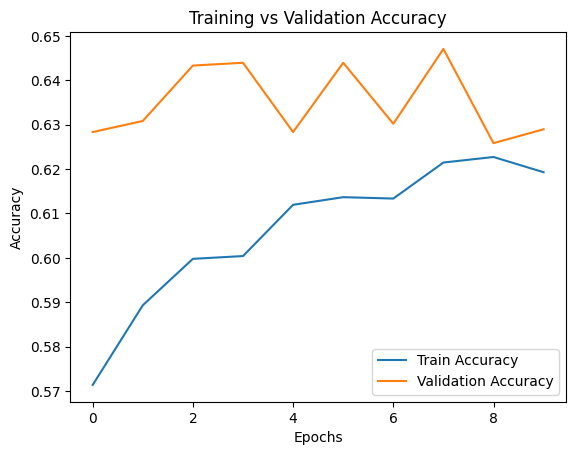

In [29]:
# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [30]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")


64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.7518 - loss: 0.6006
Test Accuracy: 0.6199
